In [55]:
# Core libraries and model utilities
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Use a consistent plot style for EDA
plt.style.use("ggplot")

In [56]:
# Load data, clean required columns, and create model-ready features
df = pd.read_csv("data/zameen.csv", sep="|")
model_df = df[["price", "city", "location", "bedrooms", "baths", "size"]].copy()

numeric_cols = ["price", "bedrooms", "baths", "size"]
model_df[numeric_cols] = model_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
model_df = model_df.dropna(subset=["city", "location"] + numeric_cols).reset_index(drop=True)

# Simulate environmental binary features using price-aware probabilities
rng = np.random.default_rng(42)
price_norm = (model_df["price"] - model_df["price"].min()) / (
    model_df["price"].max() - model_df["price"].min()
)

env_probabilities = [
    ("is_near_park", 0.20 + 0.60 * price_norm),
    ("is_near_commercial", 0.25 + 0.55 * price_norm),
    ("is_near_graveyard", 0.70 - 0.60 * price_norm),
    ("is_corner_facing", 0.25 + 0.50 * price_norm),
    ("is_near_mosque", 0.30 + 0.45 * price_norm),
    ("lacks_amenities", 0.65 - 0.50 * price_norm),
]

for feature_col, feature_prob in env_probabilities:
    model_df[feature_col] = (rng.random(len(model_df)) < feature_prob).astype(int)

encoded_df = pd.get_dummies(model_df, columns=["city", "location"], dtype=int)

print("Cleaned Data Shape:", model_df.shape)
print("Encoded Data Shape:", encoded_df.shape)
print("Cities in dataset:", model_df["city"].nunique())
model_df.head()

Cleaned Data Shape: (16019, 12)
Encoded Data Shape: (16019, 2058)
Cities in dataset: 11


,price,city,location,bedrooms,baths,size,is_near_park,is_near_commercial,is_near_graveyard,is_corner_facing,is_near_mosque,lacks_amenities
0,74500000,Lahore,"DHA Phase 6, DHA Defence",5,6,4500.0,0,0,0,0,1,0
1,51500000,Lahore,"DHA Phase 7, DHA Defence",5,6,4500.0,0,1,0,1,0,0
2,7500000,Lahore,"Dream Gardens, Defence Road",1,1,518.0,0,0,1,0,0,0
3,73000000,Lahore,"DHA Phase 6, DHA Defence",5,6,4500.0,0,0,0,0,0,0
4,5700000,Lahore,"Bahria Town - Sector B, Bahria Town",1,1,472.0,1,0,0,0,0,1


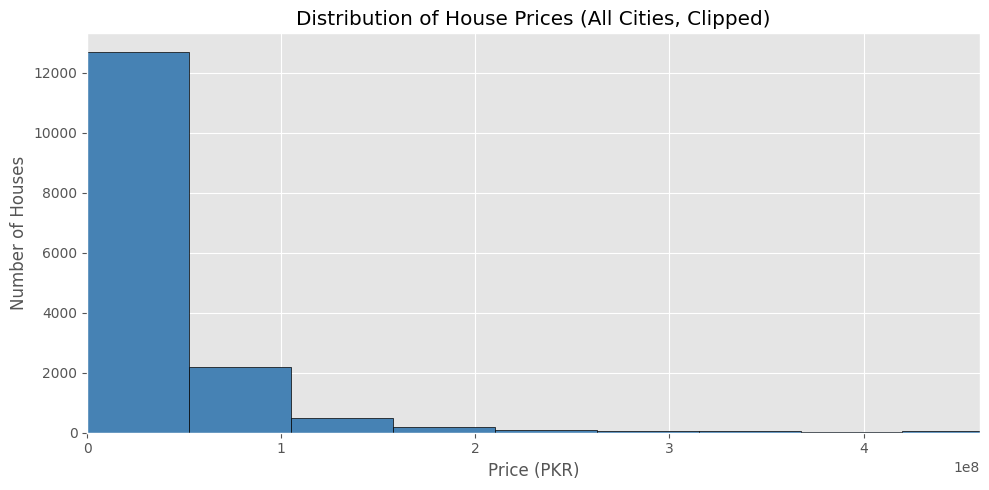

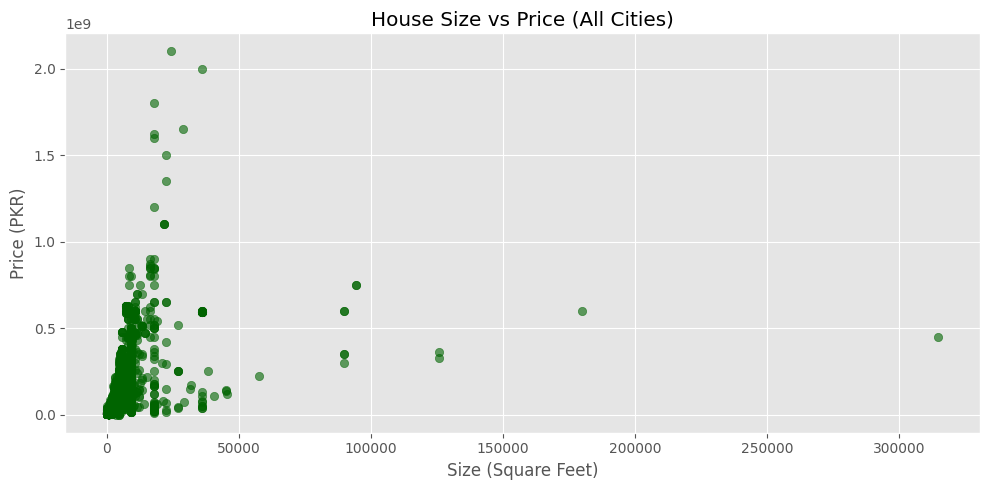

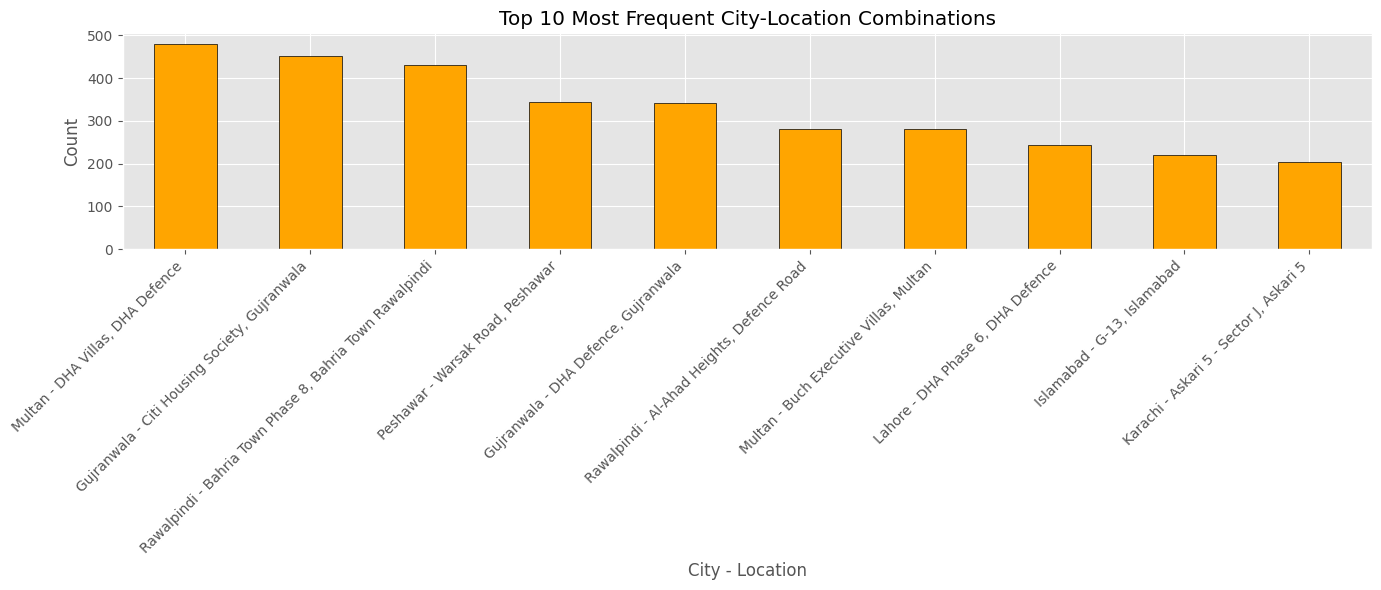

In [57]:
# Quick EDA plots for distribution and relationship checks
price_upper_limit = model_df["price"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(model_df["price"], bins=40, color="steelblue", edgecolor="black")
plt.xlim(0, price_upper_limit)
plt.title("Distribution of House Prices (All Cities, Clipped)")
plt.xlabel("Price (PKR)")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.scatter(model_df["size"], model_df["price"], alpha=0.6, color="darkgreen")
plt.title("House Size vs Price (All Cities)")
plt.xlabel("Size (Square Feet)")
plt.ylabel("Price (PKR)")
plt.tight_layout()
plt.show()

location_labels = model_df["city"] + " - " + model_df["location"]
top_10_locations = location_labels.value_counts().head(10)

plt.figure(figsize=(14, 6))
top_10_locations.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Top 10 Most Frequent City-Location Combinations")
plt.xlabel("City - Location")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [58]:
# Build features/target and perform a reproducible train-test split
X = encoded_df.drop("price", axis=1)
y = encoded_df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Number of features:", X_train.shape[1])

Training rows: 12815
Testing rows: 3204
Number of features: 2057


In [59]:
# Baseline model: Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print("=== Linear Regression Results ===")
print(f"MAE: {linear_mae:,.2f}")
print(f"R-squared: {linear_r2:.4f}")

# Show learned weights for engineered environmental features
environment_features = [
    "is_near_park",
    "is_near_commercial",
    "is_near_graveyard",
    "is_corner_facing",
    "is_near_mosque",
    "lacks_amenities",
]

print("\nLearned coefficients for environmental features:")
for feature_name in environment_features:
    feature_index = X_train.columns.get_loc(feature_name)
    feature_weight = linear_model.coef_[feature_index]
    print(f"{feature_name}: {feature_weight:,.4f}")

=== Linear Regression Results ===
MAE: 16,101,787.43
R-squared: 0.0539

Learned coefficients for environmental features:
is_near_park: 1,006,523.0415
is_near_commercial: 1,048,282.7609
is_near_graveyard: -2,127,259.6068
is_corner_facing: 2,781,599.3995
is_near_mosque: 1,275,320.3539
lacks_amenities: -2,054,933.9723


In [60]:
# Advanced model: MLPRegressor with scaling and log target transform
mlp_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "mlp",
            MLPRegressor(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=2000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=42,
            ),
        ),
    ]
)

mlp_model = TransformedTargetRegressor(
    regressor=mlp_pipeline,
    func=np.log1p,
    inverse_func=np.expm1,
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
mlp_r2 = r2_score(y_test, y_pred_mlp)

print("=== Artificial Neural Network (MLPRegressor) Results ===")
print(f"MAE: {mlp_mae:,.2f}")
print(f"R-squared: {mlp_r2:.4f}")

Traceback (most recent call last):
  File "C:\Users\huzai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gradio\queueing.py", line 856, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "C:\Users\huzai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gradio\route_utils.py", line 374, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "C:\Users\huzai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\gradio\blocks.py", line 2173, in process_api
    inputs = await self.preprocess_data(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
        block_fn, inputs, sta

=== Artificial Neural Network (MLPRegressor) Results ===
MAE: 4,692,113,255,428,302,831,616.00
R-squared: -9558976967368130828001060323328.0000


In [62]:
# Build the Gradio app with the same model logic and feature schema
import gradio as gr

feature_columns = X_train.columns.tolist()
available_cities = sorted(model_df["city"].unique().tolist())
city_to_locations = {
    city_name: sorted(
        model_df.loc[model_df["city"] == city_name, "location"].dropna().unique().tolist()
    )
    for city_name in available_cities
}

size_unit_to_sqft = {
    "Square Feet": 1.0,
    "Square Yards": 9.0,
    "Marla": 272.25,
    "Kanal": 5445.0,
    "Acre": 43560.0,
}


def update_locations(selected_city):
    locations = city_to_locations.get(selected_city, [])
    return gr.Dropdown(choices=locations, value=locations[0] if locations else None)


def predict_price(
    model_choice,
    size_value,
    size_unit,
    bedrooms,
    baths,
    city,
    location,
    near_park,
    near_commercial,
    near_graveyard,
    corner_facing,
    near_mosque,
    lacks_amenities,
):
    unit_factor = size_unit_to_sqft.get(size_unit, 1.0)
    user_size_sqft = float(size_value) * unit_factor

    user_data = {column_name: 0 for column_name in feature_columns}
    user_data.update(
        {
            "size": float(user_size_sqft),
            "bedrooms": int(bedrooms),
            "baths": int(baths),
            "is_near_park": int(near_park),
            "is_near_commercial": int(near_commercial),
            "is_near_graveyard": int(near_graveyard),
            "is_corner_facing": int(corner_facing),
            "is_near_mosque": int(near_mosque),
            "lacks_amenities": int(lacks_amenities),
        }
    )

    city_column = f"city_{city}"
    if city_column in user_data:
        user_data[city_column] = 1

    location_column = f"location_{location}" if location else ""
    if location_column in user_data:
        user_data[location_column] = 1

    user_df = pd.DataFrame([user_data], columns=feature_columns)
    predicted_price = (
        linear_model.predict(user_df)[0]
        if model_choice == "Linear Regression"
        else mlp_model.predict(user_df)[0]
    )

    base_price = max(0, float(predicted_price))
    adjusted_price = base_price * 1.10352

    return (
        "### Estimated Price\n"
        f"## PKR {base_price:,.0f}\n\n"
        "### Inflation + Interest Adjusted Price\n"
        f"## PKR {adjusted_price:,.0f}"
    )


css = """
@import url('https://fonts.googleapis.com/css2?family=Outfit:wght@400;500;600;700&display=swap');

html,
body,
.gradio-container {
    min-height: 100%;
}

body,
.gradio-container {
    background-color: #f8fafc;
    background-image:
        linear-gradient(to right, #e5e7eb 1px, transparent 1px),
        linear-gradient(to bottom, #e5e7eb 1px, transparent 1px);
    background-size: 34px 34px;
    background-position: 0 0;
    font-family: 'Outfit', 'Segoe UI', sans-serif;
}

#estimate-card {
    max-width: 560px;
    margin: 24px auto;
    padding: 24px;
    border-radius: 24px;
    border: 1px solid #d7dde5;
    background: #ffffff;
    box-shadow: 0 10px 30px rgba(15, 23, 42, 0.08);
}

.hero-title {
    text-align: center;
    font-size: 42px;
    font-weight: 700;
    letter-spacing: 0.2px;
    color: #17212f;
    line-height: 1.1;
}

.hero-subtitle {
    text-align: center;
    margin: 6px 0 18px 0;
    font-size: 16px;
    font-weight: 500;
    color: #4b5563;
}

#estimate-card .md h3 {
    color: #0b1220 !important;
    font-weight: 800 !important;
}

:root {
    --control-gray: #f1f3f6;
}

#estimate-card .pair-row {
    gap: 18px !important;
    flex-wrap: nowrap !important;
}

#estimate-card .pair-row > .form {
    display: flex !important;
    gap: 18px !important;
    width: 100% !important;
}

#estimate-card .pair-row > .form > .field-card {
    flex: 1 1 0 !important;
    min-width: 0 !important;
}

#estimate-card .pair-row > .column {
    min-width: 0 !important;
}

.field-card {
    background: transparent !important;
    border: none !important;
    border-radius: 0;
    padding: 0 !important;
    margin-bottom: 10px;
    overflow: visible !important;
}

.check-card {
    background: transparent !important;
    border: none !important;
    border-radius: 0;
    padding: 0 !important;
}

.field-card .form,
.check-card .form {
    background: transparent !important;
    --block-background-fill: transparent !important;
    border: none !important;
    box-shadow: none !important;
}

#estimate-card .form {
    background: transparent !important;
    --block-background-fill: transparent !important;
}

.field-card:not(.slider-card) .wrap {
    background: var(--control-gray) !important;
    border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important;
    box-shadow: none !important;
    overflow: hidden !important;
}

.slider-card .wrap {
    background: transparent !important;
    border: none !important;
    box-shadow: none !important;
}

.field-card .wrap-inner,
.field-card .secondary-wrap,
.field-card .icon-wrap {
    background: transparent !important;
    border: none !important;
}

.field-card input[role='listbox'] {
    color: #0f172a !important;
    opacity: 1 !important;
    padding-right: 34px !important;
}

.field-card .secondary-wrap {
    align-items: center !important;
}

.field-card .icon-wrap {
    margin-left: auto !important;
    width: 24px !important;
    min-width: 24px !important;
    display: flex !important;
    align-items: center !important;
    justify-content: center !important;
    pointer-events: none !important;
}

.field-card .icon-wrap svg,
.field-card .icon-wrap .dropdown-arrow {
    width: 18px !important;
    height: 18px !important;
    color: #0f172a !important;
    fill: #0f172a !important;
    opacity: 1 !important;
}

.field-card:not(.slider-card) input[type='number'],
.field-card input[type='text'],
.field-card textarea {
    background: var(--control-gray) !important;
    border: 1px solid #e2e8f0 !important;
    border-radius: 12px !important;
    box-shadow: none !important;
    color: #0f172a !important;
}

.slider-card button[aria-label='Reset to default value'] {
    display: none !important;
}

.slider-card .tab-like-container {
    width: 42px !important;
    min-width: 42px !important;
    max-width: 42px !important;
    height: 18px !important;
    border-radius: 999px !important;
    justify-content: center !important;
    align-items: center !important;
    margin-left: 0 !important;
}

.slider-card .head {
    justify-content: flex-start !important;
    gap: 0 !important;
}

.slider-card .head label {
    flex: 1 1 auto !important;
    max-width: calc(100% - 44px) !important;
}

.slider-card .tab-like-container input[type='number'] {
    width: 100% !important;
    height: 16px !important;
    font-size: 9px !important;
    pointer-events: none !important;
    user-select: none !important;
    caret-color: transparent !important;
}

.check-card .checkbox-container,
.check-card .label-text {
    background: transparent !important;
    color: #334155 !important;
    opacity: 1 !important;
}

.check-card input[type='checkbox'] {
    width: 16px !important;
    height: 16px !important;
    appearance: auto !important;
    -webkit-appearance: checkbox !important;
    background: #ffffff !important;
    border: 1px solid #94a3b8 !important;
    accent-color: #17212f !important;
    opacity: 1 !important;
    cursor: pointer;
}

.check-card input[type='checkbox']:checked {
    border-color: #17212f !important;
}

.estimate-btn {
    background: #17212f !important;
    border: none !important;
    color: #f8fafc !important;
    font-weight: 700 !important;
    font-size: 18px !important;
    padding: 12px 18px !important;
    border-radius: 14px !important;
}

.price-output {
    border: 1px solid #d6dce4;
    border-radius: 14px;
    background: #ffffff;
    padding: 14px 16px;
    color: #0f172a !important;
}

.price-output h1, .price-output h2, .price-output h3, .price-output p, .price-output span {
    color: #0f172a !important;
}
"""

initial_city = available_cities[0] if available_cities else None
initial_locations = city_to_locations.get(initial_city, [])

with gr.Blocks() as demo:
    with gr.Column(elem_id="estimate-card"):
        gr.HTML(
            """
            <div class='hero-title'>🏡HomeValue AI📈</div>
            <div class='hero-subtitle'>Real Estate Price Predictor</div>
            """
        )

        model_input = gr.Dropdown(
            choices=["Linear Regression", "Artificial Neural Network"],
            value="Linear Regression",
            label="Prediction Model",
            elem_classes=["field-card"],
        )

        gr.Markdown("### Property  Details")

        with gr.Row(elem_classes=["pair-row"]):
            size_value_input = gr.Number(
                value=4500.0,
                label="Size Value",
                precision=2,
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )
            size_unit_input = gr.Dropdown(
                choices=list(size_unit_to_sqft.keys()),
                value="Square Feet",
                label="Size Unit",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

        bedrooms_input = gr.Slider(
            1, 10, value=5, step=1, label="Bedrooms", elem_classes=["field-card", "slider-card"], scale=1, min_width=0
        )
        baths_input = gr.Slider(
            1, 10, value=5, step=1, label="Bathrooms", elem_classes=["field-card", "slider-card"], scale=1, min_width=0
        )

        with gr.Row(elem_classes=["pair-row"]):
            city_input = gr.Dropdown(
                choices=available_cities,
                value=initial_city,
                label="City",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

            location_input = gr.Dropdown(
                choices=initial_locations,
                value=initial_locations[0] if initial_locations else None,
                label="Location",
                elem_classes=["field-card"],
                scale=1,
                min_width=0,
            )

        gr.Markdown("### Environmental Factors")

        with gr.Row():
            near_park_input = gr.Checkbox(value=False, label="Near Park", elem_classes=["check-card"])
            near_commercial_input = gr.Checkbox(value=False, label="Near Commercial", elem_classes=["check-card"])
            near_graveyard_input = gr.Checkbox(value=False, label="Near Graveyard", elem_classes=["check-card"])

        with gr.Row():
            corner_facing_input = gr.Checkbox(value=False, label="Corner Facing", elem_classes=["check-card"])
            near_mosque_input = gr.Checkbox(value=False, label="Near Mosque", elem_classes=["check-card"])
            lacks_amenities_input = gr.Checkbox(value=False, label="Lack of Amenities", elem_classes=["check-card"])

        estimate_button = gr.Button("Calculate Estimate", elem_classes=["estimate-btn"])
        result_output = gr.Markdown(elem_classes=["price-output"])

        city_input.change(
            fn=update_locations,
            inputs=[city_input],
            outputs=[location_input],
        )

        estimate_button.click(
            fn=predict_price,
            inputs=[
                model_input,
                size_value_input,
                size_unit_input,
                bedrooms_input,
                baths_input,
                city_input,
                location_input,
                near_park_input,
                near_commercial_input,
                near_graveyard_input,
                corner_facing_input,
                near_mosque_input,
                lacks_amenities_input,
            ],
            outputs=[result_output],
        )

app, local_url, share_url = demo.launch(inline=False, share=False, prevent_thread_lock=True, css=css, theme=gr.themes.Soft())
print(f"Open in browser: {local_url}")


* Running on local URL:  http://127.0.0.1:7894
* To create a public link, set `share=True` in `launch()`.
Open in browser: http://127.0.0.1:7894/
